# Task 1 & 2: Vanilla GAN - BCE Loss vs Logistic Loss

## Task 1
Run the provided vanilla GAN implementation in [GAN.py](GAN.py) as it is. Understand every component: the data pipeline, generator, discriminator, BCE loss, and training loop.

## Task 2
Take the same code from Task 1 and swap the loss function to **logistic loss** (Brandon Amos variant). The discriminator architecture requires a minor change: remove the final sigmoid, so the network outputs raw logits instead of probabilities. Everything else stays identical to [GAN.py](GAN.py). Train for **5, 10, and 50 epochs** and compare results from both tasks.

In [1]:
# Imports identical to GAN.py, plus matplotlib for inline display
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import tqdm
import os

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

print(f"PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")

PyTorch 2.11.0+cu130  |  CUDA: True


In [2]:
# Hyperparameters taken directly from GAN.py
mb_size = 64
Z_dim   = 1000
h_dim   = 128
lr      = 1e-3
X_dim   = 784   # 28 × 28 flattened

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Data loading identical to GAN.py
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))   # flatten 28×28 → 784
])

train_dataset = datasets.MNIST(root='../MNIST', train=True, transform=transform, download=True)
train_loader  = DataLoader(train_dataset, batch_size=mb_size, shuffle=True)

print(f"MNIST loaded , {len(train_dataset)} samples , {len(train_loader)} batches/epoch")

Device: cuda:0
MNIST loaded , 60000 samples , 938 batches/epoch


In [3]:
# Xavier initialisation same as GAN.py
def xavier_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# Generator identical to GAN.py
class Generator(nn.Module):
    def __init__(self, z_dim, h_dim, x_dim):
        super().__init__()
        self.fc1 = nn.Linear(z_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, x_dim)
        self.apply(xavier_init)

    def forward(self, z):
        h   = F.relu(self.fc1(z))
        out = torch.sigmoid(self.fc2(h))
        return out

# Discriminator for Task 1 / BCE identical to GAN.py (sigmoid output)
class Discriminator(nn.Module):
    def __init__(self, x_dim, h_dim):
        super().__init__()
        self.fc1 = nn.Linear(x_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, 1)
        self.apply(xavier_init)

    def forward(self, x):
        h   = F.relu(self.fc1(x))
        out = torch.sigmoid(self.fc2(h))
        return out

# Discriminator for Task 2 / Logistic loss - same architecture, sigmoid REMOVED
# The only difference from GAN.py is that fc2 outputs raw logits.
class DiscriminatorLogits(nn.Module):
    def __init__(self, x_dim, h_dim):
        super().__init__()
        self.fc1 = nn.Linear(x_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, 1)
        self.apply(xavier_init)

    def forward(self, x):
        h   = F.relu(self.fc1(x))
        out = self.fc2(h)        # raw logits-no sigmoid
        return out

print("Models defined")

Models defined


In [4]:
# Sample-saving utility, mirrors save_sample() in GAN.py
def save_sample(G, epoch, out_dir):
    G.eval()
    with torch.no_grad():
        z       = torch.randn(mb_size, Z_dim).to(device)
        samples = G(z).detach().cpu().numpy()[:16]

    fig = plt.figure(figsize=(4, 4))
    gs  = gridspec.GridSpec(4, 4)
    gs.update(wspace=0.05, hspace=0.05)

    for i, sample in enumerate(samples):
        ax = plt.subplot(gs[i])
        plt.axis('off')
        ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_aspect('equal')
        plt.imshow(sample.reshape(28, 28), cmap='Greys_r')

    os.makedirs(out_dir, exist_ok=True)
    plt.savefig(os.path.join(out_dir, f'{str(epoch).zfill(3)}.png'), bbox_inches='tight')
    plt.close(fig)

print("Utility functions defined")

Utility functions defined


In [5]:
# Task 1 BCE training epoch
# Mirrors cGANTraining() in GAN.py

def bce_training_epoch(G, D, G_solver, D_solver, train_loader):
    G.train(); D.train()

    D_loss_real_total = 0.0
    D_loss_fake_total = 0.0
    G_loss_total      = 0.0

    t = tqdm.tqdm(train_loader, leave=False)
    for X_real, _ in t:
        X_real     = X_real.float().to(device)
        batch_size = X_real.size(0)

        z           = torch.randn(batch_size, Z_dim).to(device)
        ones_label  = torch.ones(batch_size, 1).to(device)
        zeros_label = torch.zeros(batch_size, 1).to(device)

        # Discriminator step (identical to GAN.py)
        G_sample = G(z)
        D_real   = D(X_real)
        D_fake   = D(G_sample.detach())

        D_loss_real = F.binary_cross_entropy(D_real, ones_label)
        D_loss_fake = F.binary_cross_entropy(D_fake, zeros_label)
        D_loss      = D_loss_real + D_loss_fake

        D_loss_real_total += D_loss_real.item()
        D_loss_fake_total += D_loss_fake.item()

        D_solver.zero_grad(); D_loss.backward(); D_solver.step()

        # Generator step (identical to GAN.py)
        z        = torch.randn(batch_size, Z_dim).to(device)
        G_sample = G(z)
        D_fake   = D(G_sample)

        G_loss = F.binary_cross_entropy(D_fake, ones_label)
        G_loss_total += G_loss.item()

        G_solver.zero_grad(); G_loss.backward(); G_solver.step()

    n = len(train_loader)
    D_real_avg = D_loss_real_total / n
    D_fake_avg = D_loss_fake_total / n
    return G_loss_total / n, D_real_avg + D_fake_avg, D_real_avg, D_fake_avg


# Task 2 Logistic-loss training epoch
# Mirrors cGANTraining() structure exactly.
# Only changes: discriminator outputs raw logits (no sigmoid),
# and the loss uses softplus instead of BCE.
def logistic_training_epoch(G, D, G_solver, D_solver, train_loader):
    G.train(); D.train()

    D_loss_real_total = 0.0
    D_loss_fake_total = 0.0
    G_loss_total      = 0.0

    t = tqdm.tqdm(train_loader, leave=False)
    for X_real, _ in t:
        X_real     = X_real.float().to(device)
        batch_size = X_real.size(0)

        z = torch.randn(batch_size, Z_dim).to(device)

        # Discriminator step (identical to GAN.py)
        G_sample    = G(z)
        real_logits = D(X_real)
        fake_logits = D(G_sample.detach())

        # softplus(−l) = log(1+exp(−l)) = −log σ(l)
        D_loss_real = F.softplus(-real_logits).mean()
        D_loss_fake = F.softplus(fake_logits).mean()
        D_loss      = D_loss_real + D_loss_fake

        D_loss_real_total += D_loss_real.item()
        D_loss_fake_total += D_loss_fake.item()

        D_solver.zero_grad(); D_loss.backward(); D_solver.step()

        # Generator step (non-saturating)
        z           = torch.randn(batch_size, Z_dim).to(device)
        G_sample    = G(z)
        fake_logits = D(G_sample)

        G_loss = F.softplus(-fake_logits).mean()
        G_loss_total += G_loss.item()

        G_solver.zero_grad(); G_loss.backward(); G_solver.step()

    n = len(train_loader)
    D_real_avg = D_loss_real_total / n
    D_fake_avg = D_loss_fake_total / n
    return G_loss_total / n, D_real_avg + D_fake_avg, D_real_avg, D_fake_avg

print("Training functions defined  (bce_training_epoch  |  logistic_training_epoch)")

Training functions defined  (bce_training_epoch  |  logistic_training_epoch)


## Task 1 - Complete BCE vanilla GAN

### Architecture

| Component | Details |
|-----------|---------|
| **Data** | MNIST, flattened 28×28 → 784-dim vector, values normalised to [0, 1] |
| **Generator** | Linear(1000→128) → ReLU → Linear(128→784) → Sigmoid |
| **Discriminator** | Linear(784→128) → ReLU → Linear(128→1) → **Sigmoid** |
| **G objective** | Non-minimax: $\mathcal{L}_G = -\mathbb{E}_z[\log D(G(z))]$ |
| **D objective** | $\mathcal{L}_D = -\mathbb{E}_x[\log D(x)] - \mathbb{E}_z[\log(1-D(G(z)))]$ |
| **Optimiser** | Adam, lr = 1e-3 (both G and D) |
| **Epochs in notebook** | 5 / 10 / 50 - same durations as Task 2 for direct comparison |


In [6]:
# Task 1 — Run BCE GAN
# Runs for 5, 10, and 50 epochs to match Task 2 for direct comparison

BASE_OUT     = "outputs_GAN"      # all files go under this folder
os.makedirs(BASE_OUT, exist_ok=True)

epoch_counts = [5, 10, 50]
bce_runs     = {}

for num_epochs in epoch_counts:
    print(f"  BCE GAN (Task 1)  |  {num_epochs} epochs")

    G = Generator(Z_dim, h_dim, X_dim).to(device)
    D = Discriminator(X_dim, h_dim).to(device)       # sigmoid output

    G_solver = optim.Adam(G.parameters(), lr=lr)
    D_solver = optim.Adam(D.parameters(), lr=lr)

    out_dir        = os.path.join(BASE_OUT, f"bce_{num_epochs}ep")
    checkpoint_dir = os.path.join(out_dir, "checkpoints")
    os.makedirs(checkpoint_dir, exist_ok=True)

    history     = {'G_loss': [], 'D_loss': [], 'D_real': [], 'D_fake': []}
    best_g_loss = float('inf')

    for epoch in range(num_epochs):
        G_avg, D_avg, D_real_avg, D_fake_avg = bce_training_epoch(
            G, D, G_solver, D_solver, train_loader
        )

        history['G_loss'].append(G_avg)
        history['D_loss'].append(D_avg)
        history['D_real'].append(D_real_avg)
        history['D_fake'].append(D_fake_avg)

        save_sample(G, epoch, out_dir)

        if G_avg < best_g_loss:
            best_g_loss = G_avg
            torch.save(G.state_dict(), os.path.join(checkpoint_dir, 'G_best.pth'))
            torch.save(D.state_dict(), os.path.join(checkpoint_dir, 'D_best.pth'))

        print(f"epoch {epoch:2d}  |  D_loss: {D_avg:.4f}  "
              f"(real: {D_real_avg:.4f}, fake: {D_fake_avg:.4f})  |  G_loss: {G_avg:.4f}")

    bce_runs[num_epochs] = {
        'G': G, 'D': D,
        'history': history,
        'best_g_loss': best_g_loss,
        'out_dir': out_dir,
    }
    print(f"Saved to {out_dir}/  |  Best G_loss: {best_g_loss:.4f}")

print("\n\nTask 1 complete — BCE runs for 5 / 10 / 50 epochs finished.")


  BCE GAN (Task 1)  |  5 epochs


epoch  0  |  D_loss: 0.0633  (real: 0.0418, fake: 0.0215)  |  G_loss: 6.5337


epoch  1  |  D_loss: 0.0411  (real: 0.0214, fake: 0.0197)  |  G_loss: 6.0799


epoch  2  |  D_loss: 0.0741  (real: 0.0378, fake: 0.0363)  |  G_loss: 4.8497


epoch  3  |  D_loss: 0.1299  (real: 0.0753, fake: 0.0545)  |  G_loss: 4.8300


...

epoch 45  |  D_loss: 0.5571  (real: 0.2976, fake: 0.2595)  |  G_loss: 2.9140


epoch 46  |  D_loss: 0.5466  (real: 0.2932, fake: 0.2533)  |  G_loss: 2.9181


epoch 47  |  D_loss: 0.5386  (real: 0.2917, fake: 0.2469)  |  G_loss: 2.9374


epoch 48  |  D_loss: 0.5367  (real: 0.2914, fake: 0.2453)  |  G_loss: 2.9544


epoch 49  |  D_loss: 0.5261  (real: 0.2884, fake: 0.2376)  |  G_loss: 2.9506
Saved to outputs_GAN/bce_50ep/  |  Best G_loss: 2.1951


Task 1 complete — BCE runs for 5 / 10 / 50 epochs finished.


## Task 2 - Same Code, Logistic Loss

### What changes compared to GAN.py / Task 1

| | Task 1 (GAN.py / this notebook) | Task 2 (this notebook) |
|---|---|---|
| **Discriminator output** | `sigmoid(fc2(h))` ∈ [0, 1] | `fc2(h)` - raw logits ∈ ℝ |
| **D loss** | `BCE(D(x), 1) + BCE(D(G(z)), 0)` | `softplus(−D(x)) + softplus(D(G(z)))` |
| **G loss** | `BCE(D(G(z)), 1)` | `softplus(−D(G(z)))` - non-saturating |
| **Architecture** | same | same |
| **Hyperparameters** | same | same |
| **Epochs** | 5, 10, 50 | 5, 10, 50 |

### Why remove sigmoid from the discriminator?
With raw logits the loss function can be written directly in terms of `softplus`, which is equivalent to the logistic cross-entropy but avoids the numerical issue of computing `log(sigmoid(x))` when `x` is very negative. The gradient signal is the same as BCE but with better numerical properties.


In [7]:
# Task 2 train the same GAN with logistic loss for 5, 10, and 50 epochs
epoch_counts    = [5, 10, 50]
logistic_runs   = {}

for num_epochs in epoch_counts:
    print(f"  Logistic-loss GAN  |  {num_epochs} epochs")

    # Instantiate models
    G = Generator(Z_dim, h_dim, X_dim).to(device)
    D = DiscriminatorLogits(X_dim, h_dim).to(device)   #no final sigmoid

    # Optimisers
    G_solver = optim.Adam(G.parameters(), lr=lr)
    D_solver = optim.Adam(D.parameters(), lr=lr)

    out_dir        = os.path.join(BASE_OUT, f"logistic_{num_epochs}ep")
    checkpoint_dir = os.path.join(out_dir, "checkpoints")
    os.makedirs(checkpoint_dir, exist_ok=True)

    history = {'G_loss': [], 'D_loss': [], 'D_real': [], 'D_fake': []}
    best_g_loss = float('inf')

    for epoch in range(num_epochs):
        G_avg, D_avg, D_real_avg, D_fake_avg = logistic_training_epoch(
            G, D, G_solver, D_solver, train_loader
        )

        history['G_loss'].append(G_avg)
        history['D_loss'].append(D_avg)
        history['D_real'].append(D_real_avg)
        history['D_fake'].append(D_fake_avg)

        save_sample(G, epoch, out_dir)

        if G_avg < best_g_loss:
            best_g_loss = G_avg
            torch.save(G.state_dict(), os.path.join(checkpoint_dir, 'G_best.pth'))
            torch.save(D.state_dict(), os.path.join(checkpoint_dir, 'D_best.pth'))

        print(f"epoch {epoch:2d}  |  D_loss: {D_avg:.4f}  "
              f"(real: {D_real_avg:.4f}, fake: {D_fake_avg:.4f})  |  G_loss: {G_avg:.4f}")

    logistic_runs[num_epochs] = {
        'G': G, 'D': D,
        'history': history,
        'best_g_loss': best_g_loss,
        'out_dir': out_dir,
    }
    print(f"\nSaved to {out_dir}/  |  Best G_loss: {best_g_loss:.4f}")

print("\n\nTask 2 complete : all three runs finished.")

  Logistic-loss GAN  |  5 epochs


epoch  0  |  D_loss: 0.0689  (real: 0.0463, fake: 0.0226)  |  G_loss: 6.9934


epoch  1  |  D_loss: 0.0189  (real: 0.0093, fake: 0.0095)  |  G_loss: 6.8990


epoch  2  |  D_loss: 0.0163  (real: 0.0087, fake: 0.0076)  |  G_loss: 6.9725


epoch  3  |  D_loss: 0.0530  (real: 0.0291, fake: 0.0239)  |  G_loss: 6.0683


...

epoch 45  |  D_loss: 0.5009  (real: 0.2705, fake: 0.2305)  |  G_loss: 3.0942


epoch 46  |  D_loss: 0.4954  (real: 0.2685, fake: 0.2269)  |  G_loss: 3.0870


epoch 47  |  D_loss: 0.4888  (real: 0.2660, fake: 0.2228)  |  G_loss: 3.0921


epoch 48  |  D_loss: 0.4867  (real: 0.2663, fake: 0.2203)  |  G_loss: 3.1269


epoch 49  |  D_loss: 0.4868  (real: 0.2675, fake: 0.2193)  |  G_loss: 3.0972

Saved to outputs_GAN/logistic_50ep/  |  Best G_loss: 2.5478


Task 2 complete : all three runs finished.


## Loss Curves: BCE (Task 1) vs Logistic (Task 2)

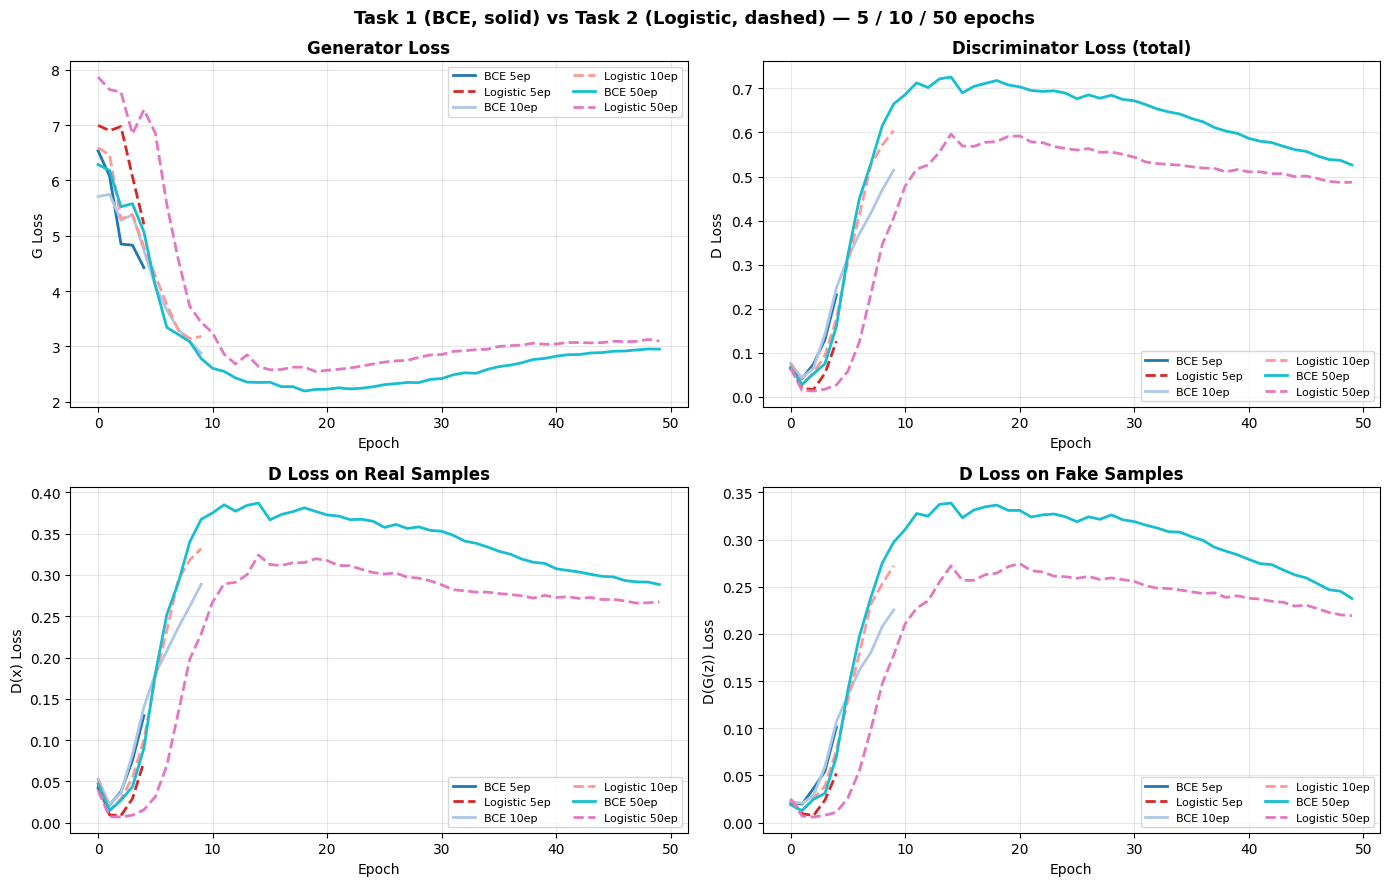

Saved: outputs_GAN/task1_vs_task2_loss.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
styles = {
    'BCE':      {'ls': '-',  'colours': {5: '#1f77b4', 10: '#aec7e8', 50: '#17becf'}},
    'Logistic': {'ls': '--', 'colours': {5: '#d62728', 10: '#ff9896', 50: '#e377c2'}},
}

for n in epoch_counts:
    epochs_x = list(range(n))
    bh = bce_runs[n]['history']
    lh = logistic_runs[n]['history']

    axes[0, 0].plot(epochs_x, bh['G_loss'], ls='-',  color=styles['BCE']['colours'][n],
                    lw=2, label=f'BCE {n}ep')
    axes[0, 0].plot(epochs_x, lh['G_loss'], ls='--', color=styles['Logistic']['colours'][n],
                    lw=2, label=f'Logistic {n}ep')

    axes[0, 1].plot(epochs_x, bh['D_loss'], ls='-',  color=styles['BCE']['colours'][n],
                    lw=2, label=f'BCE {n}ep')
    axes[0, 1].plot(epochs_x, lh['D_loss'], ls='--', color=styles['Logistic']['colours'][n],
                    lw=2, label=f'Logistic {n}ep')

    axes[1, 0].plot(epochs_x, bh['D_real'], ls='-',  color=styles['BCE']['colours'][n],
                    lw=2, label=f'BCE {n}ep')
    axes[1, 0].plot(epochs_x, lh['D_real'], ls='--', color=styles['Logistic']['colours'][n],
                    lw=2, label=f'Logistic {n}ep')

    axes[1, 1].plot(epochs_x, bh['D_fake'], ls='-',  color=styles['BCE']['colours'][n],
                    lw=2, label=f'BCE {n}ep')
    axes[1, 1].plot(epochs_x, lh['D_fake'], ls='--', color=styles['Logistic']['colours'][n],
                    lw=2, label=f'Logistic {n}ep')

titles   = ['Generator Loss', 'Discriminator Loss (total)',
            'D Loss on Real Samples', 'D Loss on Fake Samples']
ylabels  = ['G Loss', 'D Loss', 'D(x) Loss', 'D(G(z)) Loss']

for ax, title, ylabel in zip(axes.flat, titles, ylabels):
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)

plt.suptitle('Task 1 (BCE, solid) vs Task 2 (Logistic, dashed) — 5 / 10 / 50 epochs',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_OUT, 'task1_vs_task2_loss.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {BASE_OUT}/task1_vs_task2_loss.png")


## Generated Samples : Task 1 (BCE) vs Task 2 (Logistic)

Each grid shows 16 images generated after training. Both tasks are shown side-by-side at 5, 10, and 50 epochs so the effect of training duration and loss function can be compared directly.


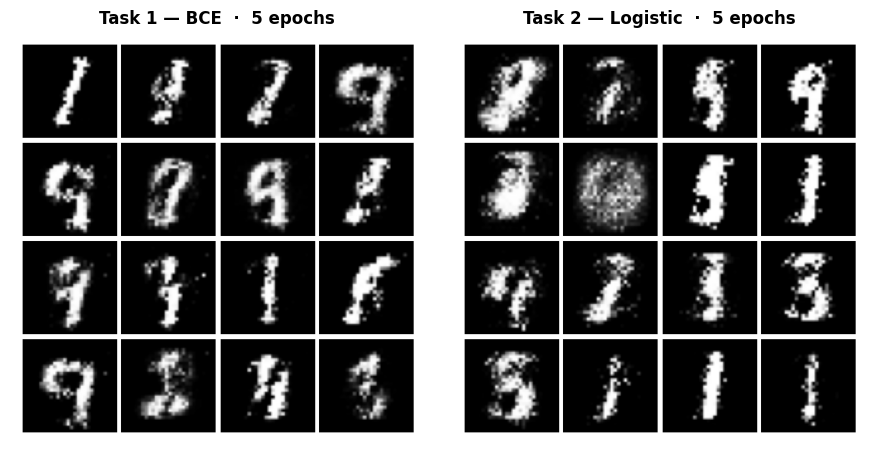

Saved: outputs_GAN/comparison_5ep.png


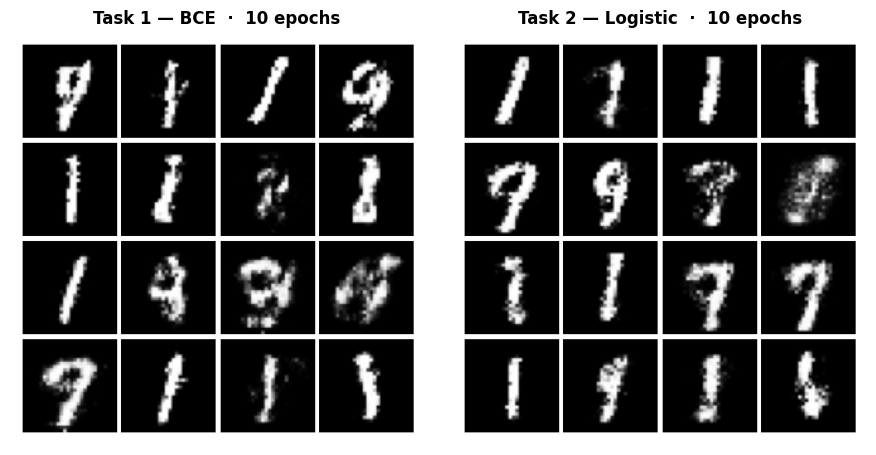

Saved: outputs_GAN/comparison_10ep.png


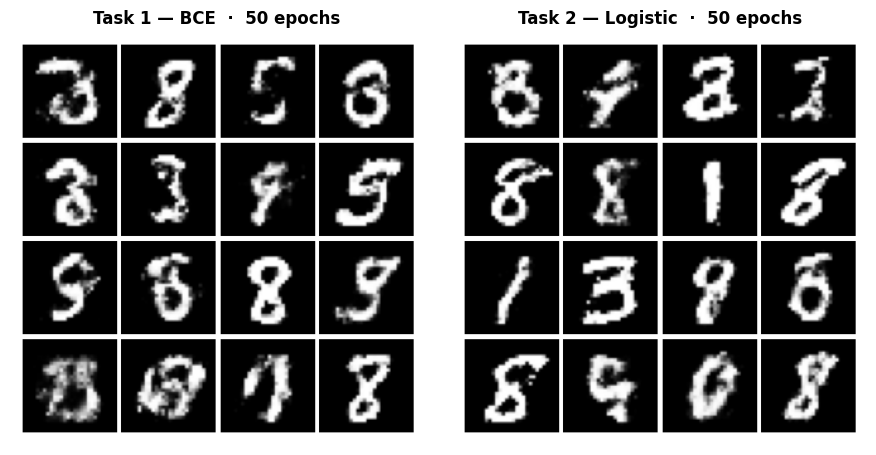

Saved: outputs_GAN/comparison_50ep.png

All sample comparisons displayed


In [9]:
import io

def generate_grid(G):
    """Render a 4×4 sample grid and return it as a numpy RGB array."""
    G.eval()
    with torch.no_grad():
        z       = torch.randn(16, Z_dim).to(device)
        samples = G(z).detach().cpu().numpy()

    fig = plt.figure(figsize=(4, 4))
    gs  = gridspec.GridSpec(4, 4)
    gs.update(wspace=0.05, hspace=0.05)
    for i, s in enumerate(samples):
        ax = plt.subplot(gs[i])
        plt.axis('off'); ax.set_aspect('equal')
        plt.imshow(s.reshape(28, 28), cmap='Greys_r')

    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    img = plt.imread(buf)
    plt.close(fig)
    return img


# Side-by-side comparison: BCE (Task 1) vs Logistic (Task 2) at each epoch count
for n in epoch_counts:
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))

    axes[0].imshow(generate_grid(bce_runs[n]['G']))
    axes[0].set_title(f'Task 1 — BCE  ·  {n} epochs', fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(generate_grid(logistic_runs[n]['G']))
    axes[1].set_title(f'Task 2 — Logistic  ·  {n} epochs', fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(BASE_OUT, f'comparison_{n}ep.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {BASE_OUT}/comparison_{n}ep.png")

print("\nAll sample comparisons displayed")


## Summary : Task 1 (BCE) vs Task 2 (Logistic)


In [10]:
import pandas as pd

rows = []
for n in epoch_counts:
    bh = bce_runs[n]['history']
    lh = logistic_runs[n]['history']
    rows += [
        {
            'Task':           'Task 1 — BCE',
            'Epochs':         n,
            'G loss (ep 1)':  f"{bh['G_loss'][0]:.4f}",
            'G loss (final)': f"{bh['G_loss'][-1]:.4f}",
            'Best G loss':    f"{bce_runs[n]['best_g_loss']:.4f}",
            'D loss (final)': f"{bh['D_loss'][-1]:.4f}",
        },
        {
            'Task':           'Task 2 — Logistic',
            'Epochs':         n,
            'G loss (ep 1)':  f"{lh['G_loss'][0]:.4f}",
            'G loss (final)': f"{lh['G_loss'][-1]:.4f}",
            'Best G loss':    f"{logistic_runs[n]['best_g_loss']:.4f}",
            'D loss (final)': f"{lh['D_loss'][-1]:.4f}",
        },
    ]

df = pd.DataFrame(rows)
print(df.to_string(index=False))


             Task  Epochs G loss (ep 1) G loss (final) Best G loss D loss (final)
     Task 1 — BCE       5        6.5337         4.4234      4.4234         0.2312
Task 2 — Logistic       5        6.9934         5.2053      5.2053         0.1260
     Task 1 — BCE      10        5.7092         2.8778      2.8778         0.5142
Task 2 — Logistic      10        6.5904         3.1806      3.1453         0.6042
     Task 1 — BCE      50        6.2864         2.9506      2.1951         0.5261
Task 2 — Logistic      50        7.8671         3.0972      2.5478         0.4868


## Why Are the Outputs Different? Task 1 (BCE) vs Task 2 (Logistic)

Both losses optimise the same underlying objective — minimising the Jensen-Shannon Divergence between the real data distribution and the generator distribution. Despite this shared foundation, the outputs look noticeably different, and the reason comes down to **how gradients flow to the generator** during training.

### Task 1 BCE Results

In Task 1 the discriminator outputs a probability via sigmoid, and the generator is trained with Binary Cross-Entropy loss. In early training the discriminator quickly learns to distinguish real from fake, pushing its confidence toward 1 for real images and 0 for fakes. Once this happens the sigmoid output saturates, and the gradient that flows back to the generator becomes extremely small close to zero. This is the **vanishing gradient problem** in GANs. As a result, at 5 epochs the generated images are noisy and largely unstructured. At 10 epochs there is slight improvement but the generator is still struggling to receive a useful learning signal. By 50 epochs the generator has had enough updates to start producing recognisable digit shapes, but the convergence is slow and uneven because of the saturation effect throughout training.

### Task 2 Logistic Loss Results

In Task 2 the sigmoid is removed from the discriminator, so it outputs raw logits. The loss is computed with softplus, which is mathematically equivalent to the logistic cross-entropy but without the numerical saturation issue. The key difference is that the gradient of softplus never goes to zero even when the discriminator is very confident, it still passes a usable signal back to the generator. This means the generator keeps learning consistently from the very first epoch. At 5 epochs the samples are already more structured than the BCE 5-epoch result. At 10 epochs they are cleaner still, and by 50 epochs the generated digits are sharper and more diverse. The loss curves are also smoother, with less oscillation compared to BCE.

### Summary

The output quality difference is most visible at **5 and 10 epochs**, where the logistic loss generator has a clear advantage due to uninterrupted gradient flow. By 50 epochs both approaches produce recognisable digits, but the logistic loss model converges more reliably. The architecture change required is minimal only the final sigmoid of the discriminator is removed yet the impact on training stability is significant.
